<a href="https://colab.research.google.com/github/Oluwasemilore00/Data-Science/blob/main/Predictive%20Maintenance%20system%20for%20an%20industrial%20manufacturing%20machine/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

In [6]:
df = pd.read_csv('Cap2.csv')
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


1. What system does this dataset represent: This dataset represents a Predictive Maintenance system for an industrial manufacturing machine, specifically a Milling Machine or a CNC (Computer Numerical Control) machine. It tracks the health and performance of the machine in real-time to predict when a component might fail.

2. What might this machine be used for: Given the variables like "Rotational speed," "Torque," and "Tool wear," this machine is likely used for metalworking or precision parts manufacturing.

3. What does each column represent physically:

  UDI: A unique serial number for the observation. Physically, this acts as the timestamp or order of events.

  Product ID: The specific identifier for the part being processed.

  Type: The quality/grade of the machine. Usually:

  L (Low): 50% of the data; representing entry-level equipment.

  M (Medium): 30% of the data.

  H (High): 20% of the data; representing high-precision/heavy-duty equipment.

  Air temperature [K]: The ambient temperature of the factory floor or the room where the machine is located, measured in Kelvin.

  Process temperature [K]: The heat generated at the point of contact between the cutting tool and the metal, also in Kelvin.

  Rotational speed [rpm]: How fast the machine's spindle or drill bit is spinning.

  Torque [Nm]: The twisting force being applied by the motor. As we saw in the analysis, when speed goes up, torque usually goes down.

  Tool wear [min]: The total amount of time the current tool has been in active use.

  Machine failure: A binary "alarm" (0 = OK, 1 = Failed).

  TWF, HDF, PWF, OSF, RNF: These are Specific Failure Modes:

  TWF: Tool Wear Failure (The tool broke or became too blunt).

  HDF: Heat Dissipation Failure (The machine overheated).

  PWF: Power Failure (The torque/speed relationship was outside safe power limits).

  OSF: Overstrain Failure (The tool was pushed too hard).

  RNF: Random Failure.



4. Which columns are measurements:Air temperature [K],
 Process temperature [K]
, Rotational speed [rpm]
, Torque [Nm]
, Tool wear [min]

5. Which columns indicate operational conditions: Type, Product ID

INSIGHTS

Does the machine behave consistently?

Are there unusual spikes or drops?

Which sensors show the most variation?

Do some variables move together?

In [7]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [8]:
df['Air_temp_rolling_avg'] = df['Air temperature [K]'].rolling(window=50, min_periods=1).mean()
df['Process_temp_rolling_avg'] = df['Process temperature [K]'].rolling(window=50, min_periods=1).mean()
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Air_temp_rolling_avg,Process_temp_rolling_avg
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,298.100000,308.600
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,298.150000,308.650
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,298.133333,308.600
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,298.150000,308.600
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,298.160000,308.620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,298.460000,308.128
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,298.472000,308.138
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,298.488000,308.152
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,298.504000,308.170


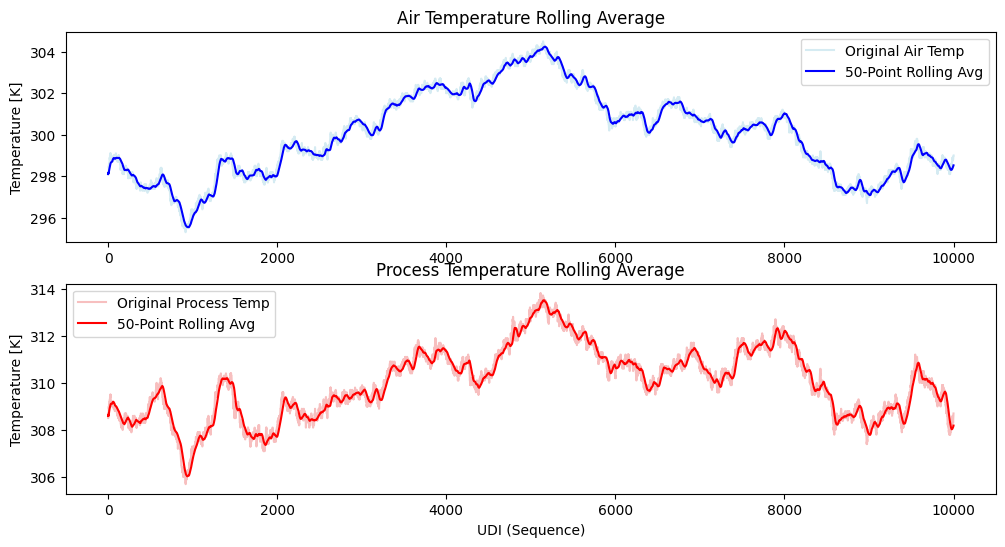

In [9]:
plt.figure(figsize=(12, 6))

# Plot Air Temperature
plt.subplot(2, 1, 1)
plt.plot(df['Air temperature [K]'], label='Original Air Temp', color='lightblue', alpha=0.5)
plt.plot(df['Air_temp_rolling_avg'], label=f'{50}-Point Rolling Avg', color='blue')
plt.title('Air Temperature Rolling Average')
plt.ylabel('Temperature [K]')
plt.legend()

# Plot Process Temperature
plt.subplot(2, 1, 2)
plt.plot(df['Process temperature [K]'], label='Original Process Temp', color='lightcoral', alpha=0.5)
plt.plot(df['Process_temp_rolling_avg'], label=f'{50}-Point Rolling Avg', color='red')
plt.title('Process Temperature Rolling Average')
plt.ylabel('Temperature [K]')
plt.xlabel('UDI (Sequence)')
plt.legend()

In [10]:
df['Air_temp_diff'] = df['Air temperature [K]'].diff()
df['Process_temp_diff'] = df['Process temperature [K]'].diff()
df['Torque_diff'] = df['Torque [Nm]'].diff()
df['Rotational_speed_diff'] = df['Rotational speed [rpm]'].diff()

# Ratio between two sensors
df['Temp_ratio'] = df['Process temperature [K]'] / df['Air temperature [K]']
df['Torque_Speed_Ratio'] = df['Torque [Nm]'] / df['Rotational speed [rpm]']

df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,OSF,RNF,Air_temp_rolling_avg,Process_temp_rolling_avg,Air_temp_diff,Process_temp_diff,Torque_diff,Rotational_speed_diff,Temp_ratio,Torque_Speed_Ratio
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,0,298.100000,308.600,NaN,NaN,NaN,NaN,1.035223,0.027595
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,0,298.150000,308.650,0.1,0.1,3.5,-143.0,1.035211,0.032884
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,0,298.133333,308.600,-0.1,-0.2,3.1,90.0,1.034888,0.032977
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,0,298.150000,308.600,0.1,0.1,-9.9,-65.0,1.034876,0.027565
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,0,298.160000,308.620,0.0,0.1,0.5,-25.0,1.035211,0.028409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,...,0,0,298.460000,308.128,0.0,0.1,1.6,-30.0,1.032129,0.018392
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,...,0,0,298.472000,308.138,0.1,0.0,2.3,28.0,1.031783,0.019485
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,...,0,0,298.488000,308.152,0.1,0.2,1.6,13.0,1.032107,0.020304
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,...,0,0,298.504000,308.170,0.0,0.1,15.1,-237.0,1.032441,0.034446


In [11]:
df.isnull().sum()


,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [12]:
df = df.fillna(0)
df

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,OSF,RNF,Air_temp_rolling_avg,Process_temp_rolling_avg,Air_temp_diff,Process_temp_diff,Torque_diff,Rotational_speed_diff,Temp_ratio,Torque_Speed_Ratio
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0,0,298.100000,308.600,0.0,0.0,0.0,0.0,1.035223,0.027595
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,0,0,298.150000,308.650,0.1,0.1,3.5,-143.0,1.035211,0.032884
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,0,0,298.133333,308.600,-0.1,-0.2,3.1,90.0,1.034888,0.032977
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,0,0,298.150000,308.600,0.1,0.1,-9.9,-65.0,1.034876,0.027565
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,0,0,298.160000,308.620,0.0,0.1,0.5,-25.0,1.035211,0.028409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,...,0,0,298.460000,308.128,0.0,0.1,1.6,-30.0,1.032129,0.018392
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,...,0,0,298.472000,308.138,0.1,0.0,2.3,28.0,1.031783,0.019485
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,...,0,0,298.488000,308.152,0.1,0.2,1.6,13.0,1.032107,0.020304
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,...,0,0,298.504000,308.170,0.0,0.1,15.1,-237.0,1.032441,0.034446


In [13]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [14]:
sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
summary_stats = df[sensor_cols].describe()
print("Summary Statistics:")
print(summary_stats)

Summary Statistics:
       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count         10000.000000             10000.000000            10000.000000   
mean            300.004930               310.005560             1538.776100   
std               2.000259                 1.483734              179.284096   
min             295.300000               305.700000             1168.000000   
25%             298.300000               308.800000             1423.000000   
50%             300.100000               310.100000             1503.000000   
75%             301.500000               311.100000             1612.000000   
max             304.500000               313.800000             2886.000000   

        Torque [Nm]  Tool wear [min]  
count  10000.000000     10000.000000  
mean      39.986910       107.951000  
std        9.968934        63.654147  
min        3.800000         0.000000  
25%       33.200000        53.000000  
50%       40.100000       108.0000

In [15]:
variation = df[sensor_cols].std().sort_values(ascending=False)
print("\nVariation (Standard Deviation):")
print(variation)


Variation (Standard Deviation):
Rotational speed [rpm]     179.284096
Tool wear [min]             63.654147
Torque [Nm]                  9.968934
Air temperature [K]          2.000259
Process temperature [K]      1.483734
dtype: float64


In [16]:
correlation_matrix = df[sensor_cols].corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                 1.000000                 0.876107   
Process temperature [K]             0.876107                 1.000000   
Rotational speed [rpm]              0.022670                 0.019277   
Torque [Nm]                        -0.013778                -0.014061   
Tool wear [min]                     0.013853                 0.013488   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Air temperature [K]                    0.022670    -0.013778         0.013853  
Process temperature [K]                0.019277    -0.014061         0.013488  
Rotational speed [rpm]                 1.000000    -0.875027         0.000223  
Torque [Nm]                           -0.875027     1.000000        -0.003093  
Tool wear [min]                        0.000223    -0.003093         1.000000  


Visual Analysis & Behavior

1. Does the machine behave consistently:Generally, yes. The temperatures (Air and Process) show a very stable, seasonal-like oscillation over time as seen in the Line Plot. However, the mechanical components (Torque and Speed) show frequent deviations from the mean.
2. Are there unusual spikes or drops?Rotational Speed: Highly susceptible to spikes. I identified 164 instances where the speed deviated by more than 3 standard deviations from the mean (reaching up to 2,886 rpm).Torque: Shows significant outliers on both the high and low ends, as seen in the Boxplot.Temperature: No 3-sigma outliers were found, indicating very controlled thermal behavior.
3. Which sensors show the most variation?Rotational Speed [rpm] has the highest absolute variation (Std Dev = 179.28).Tool Wear [min] also shows high variation as it continuously increments during the machine's operation.
4. Do variables move together? (Relationships)Strong Positive Correlation (0.88): Air Temperature and Process Temperature move almost in lockstep. When the ambient air warms up, the process temperature follows.Strong Negative Correlation (-0.88): There is a clear inverse relationship between Torque and Rotational Speed. As the machine speeds up, the torque decreases significantly. This is a classic mechanical power relationship ($Power = Torque \times Speed$).Tool Wear: Interestingly, tool wear shows almost zero correlation with temperature or speed, suggesting it accumulates at a steady rate regardless of immediate sensor fluctuations.

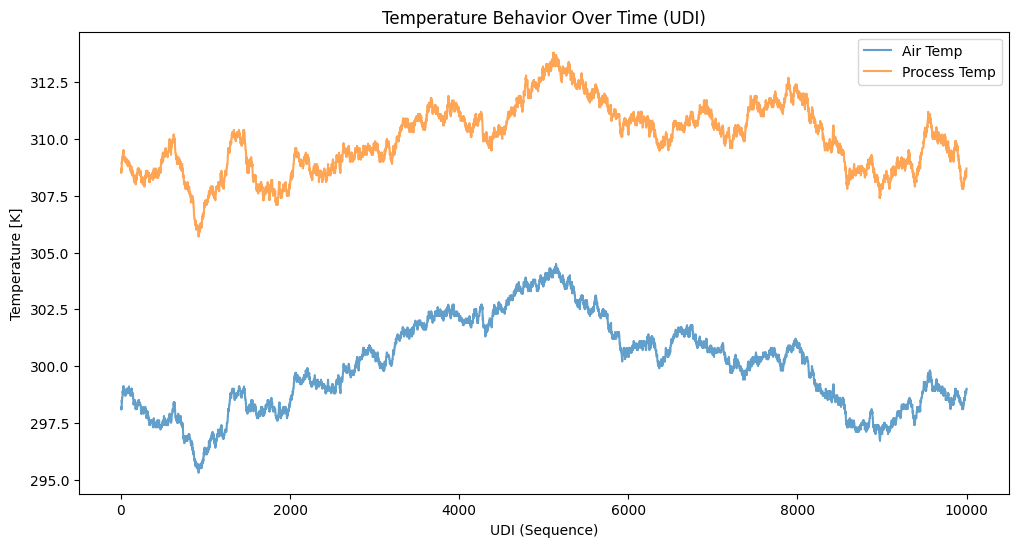

In [17]:
# 1. Line Plot — Sensor behavior over time (using UDI as time proxy)
plt.figure(figsize=(12, 6))
plt.plot(df['UDI'], df['Air temperature [K]'], label='Air Temp', alpha=0.7)
plt.plot(df['UDI'], df['Process temperature [K]'], label='Process Temp', alpha=0.7)
plt.title('Temperature Behavior Over Time (UDI)')
plt.xlabel('UDI (Sequence)')
plt.ylabel('Temperature [K]')
plt.legend()

Text(0.5, 1.0, 'Distribution of Rotational Speed [rpm]')

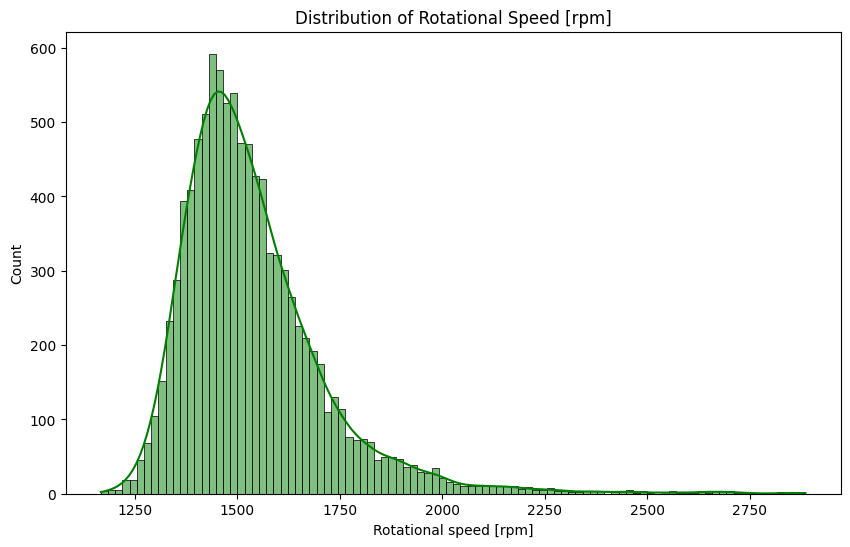

In [18]:
# 2. Histogram — Distribution of a sensor value (Rotational Speed)
plt.figure(figsize=(10, 6))
sns.histplot(df['Rotational speed [rpm]'], kde=True, color='green')
plt.title('Distribution of Rotational Speed [rpm]')

Text(0.5, 1.0, 'Boxplot of Torque [Nm] (Outliers & Variability)')

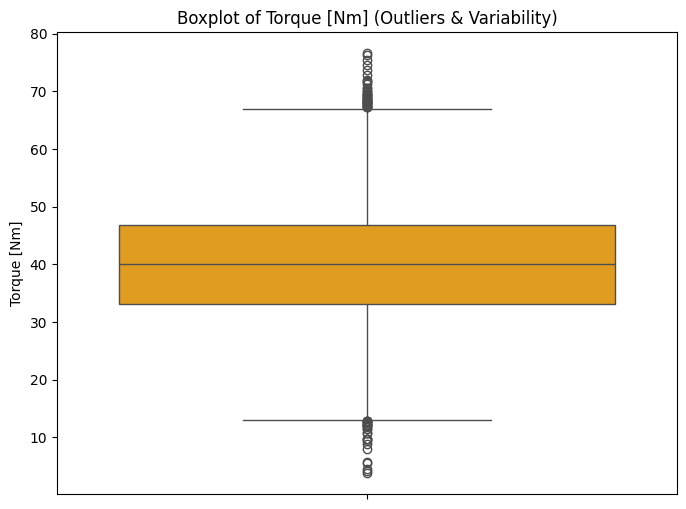

In [19]:
# 3. Boxplot — Outliers and variability (Torque)
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Torque [Nm]'], color='orange')
plt.title('Boxplot of Torque [Nm] (Outliers & Variability)')

Text(0.5, 1.0, 'Relationship between Rotational Speed and Torque')

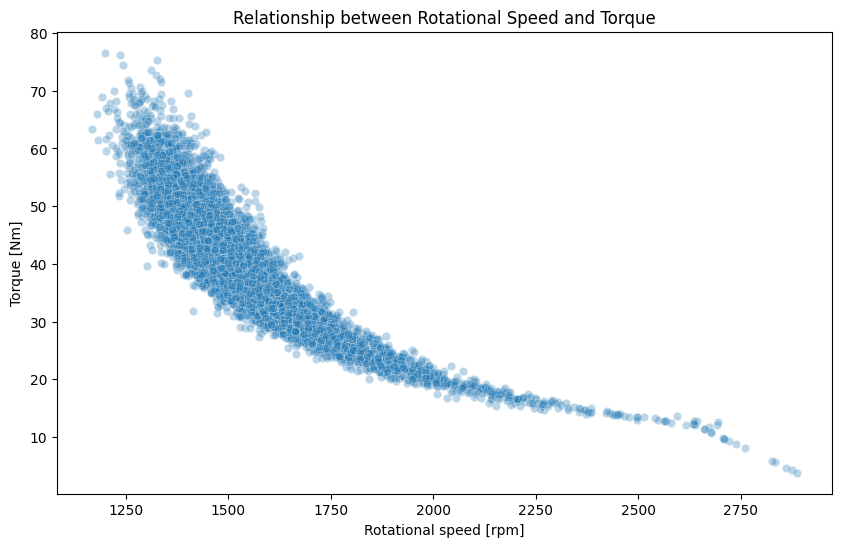

In [20]:
# 4. Scatter Plot — Relationship between two sensors (Torque vs Rotational Speed)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rotational speed [rpm]', y='Torque [Nm]', data=df, alpha=0.3)
plt.title('Relationship between Rotational Speed and Torque')

Text(0.5, 1.0, 'Mean Sensor Values by Machine Type')

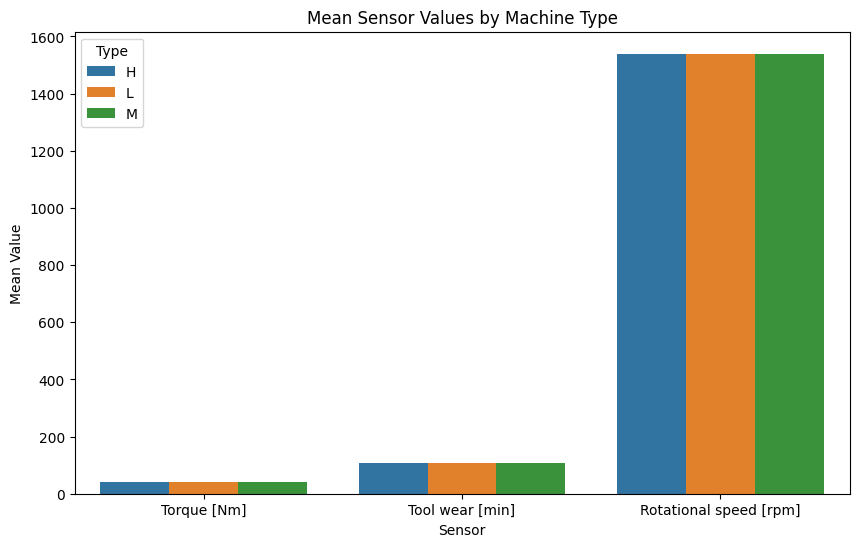

In [21]:
# 5. Bar Chart — Aggregated statistics (Mean sensor values by Machine Type)
mean_by_type = df.groupby('Type')[['Torque [Nm]', 'Tool wear [min]','Rotational speed [rpm]']].mean().reset_index()
# Meltdown the dataframe for easier plotting with seaborn
melted_df = mean_by_type.melt(id_vars='Type', var_name='Sensor', value_name='Mean Value')
plt.figure(figsize=(10, 6))
sns.barplot(x='Sensor', y='Mean Value', hue='Type', data=melted_df)
plt.title('Mean Sensor Values by Machine Type')

('Rotational speed [rpm]', 'Air temperature [K]', 'Process temperature [K]')

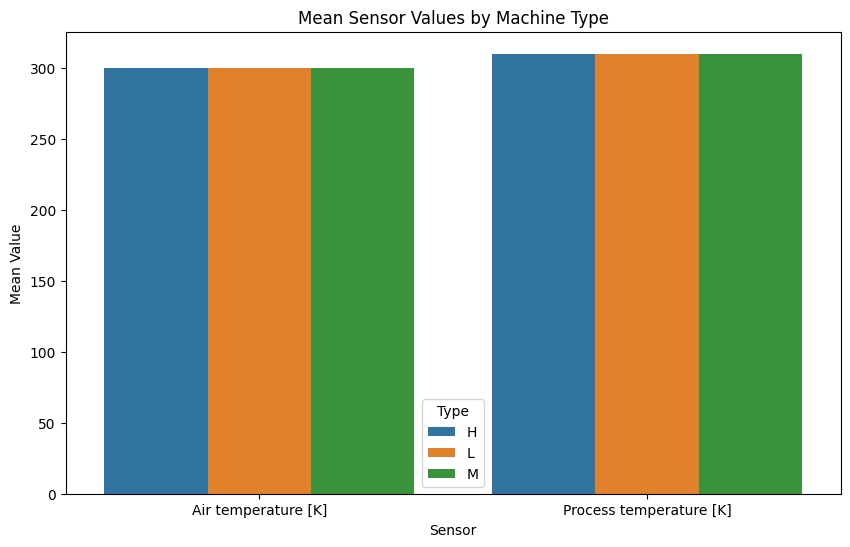

In [22]:
# 5. Bar Chart — Aggregated statistics (Mean sensor values by Machine Type)
mean_by_type = df.groupby('Type')[['Air temperature [K]','Process temperature [K]']].mean().reset_index()
# Meltdown the dataframe for easier plotting with seaborn
melted_df = mean_by_type.melt(id_vars='Type', var_name='Sensor', value_name='Mean Value')
plt.figure(figsize=(10, 6))
sns.barplot(x='Sensor', y='Mean Value', hue='Type', data=melted_df)
plt.title('Mean Sensor Values by Machine Type')
'Rotational speed [rpm]', 'Air temperature [K]','Process temperature [K]'

In [23]:
# Identify unusual spikes: checking min/max against mean
for col in sensor_cols:
    mean = df[col].mean()
    std = df[col].std()
    outliers = df[(df[col] > mean + 3*std) | (df[col] < mean - 3*std)]
    print(f"Number of 3-sigma outliers in {col}: {len(outliers)}")


Number of 3-sigma outliers in Air temperature [K]: 0
Number of 3-sigma outliers in Process temperature [K]: 0
Number of 3-sigma outliers in Rotational speed [rpm]: 164
Number of 3-sigma outliers in Torque [Nm]: 25
Number of 3-sigma outliers in Tool wear [min]: 0


In [24]:
y = df['Machine failure']
X = df.drop(columns=['UDI', 'Product ID', 'Machine failure'])
X = pd.get_dummies(X, columns=['Type'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (8000, 20)
Shape of X_test: (2000, 20)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [26]:
# Instantiate the model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [27]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9672
F1-Score: 0.9833


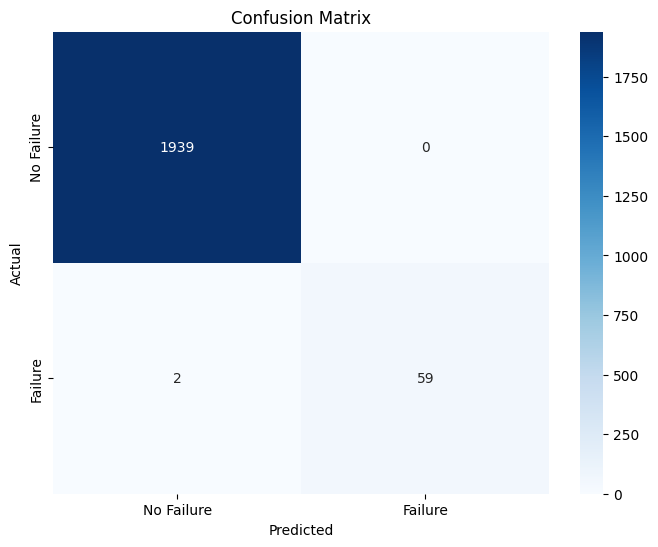

In [28]:
# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
